<a href="https://www.kaggle.com/code/gpreda/unemployment-rate-in-europe-grouped-by-countries?scriptVersionId=259190760" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introduction


Unemployment rate represents unemployed persons as a percentage of the labour force. The labour force is the total number of people employed and unemployed. Unemployed persons comprise persons aged 15 to 74 who were:   
- **a** - without work during the reference week.   
- **b** -  currently available for work, i.e. were available for paid employment or self-employment before the end of the two weeks following the reference week.   
- **c** -  actively seeking work, i.e. had taken specific steps in the four weeks period ending with the reference week to seek paid employment or self-employment or who found a job to start later, i.e. within a period of, at most, three months.   

The indicator is based on the EU Labour Force Survey.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/kaggle/input/unemployment-rate-by-sex/estat_tesem120_en.csv")

# Glimpse the data

In [3]:
df.shape

(1728, 11)

In [4]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,DATAFLOW,LAST UPDATE,freq,age,unit,sex,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2009,5.3,NaN,NaN
1,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2010,4.9,NaN,NaN
2,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2011,4.8,NaN,NaN
3,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2012,5.0,NaN,NaN
4,ESTAT:TESEM120(1.0),12/06/25 23:00:00,A,Y15-74,PC_ACT,F,AT,2013,5.5,NaN,NaN


In [5]:
df.sex.value_counts()

sex
F    576
M    576
T    576
Name: count, dtype: int64

In [6]:
df.age.value_counts()

age
Y15-74    1728
Name: count, dtype: int64

# Cleaning and configs

In [7]:
df = df.replace([np.inf, -np.inf], np.nan)

In [8]:
import warnings
warnings.filterwarnings("ignore")

# Data exploration

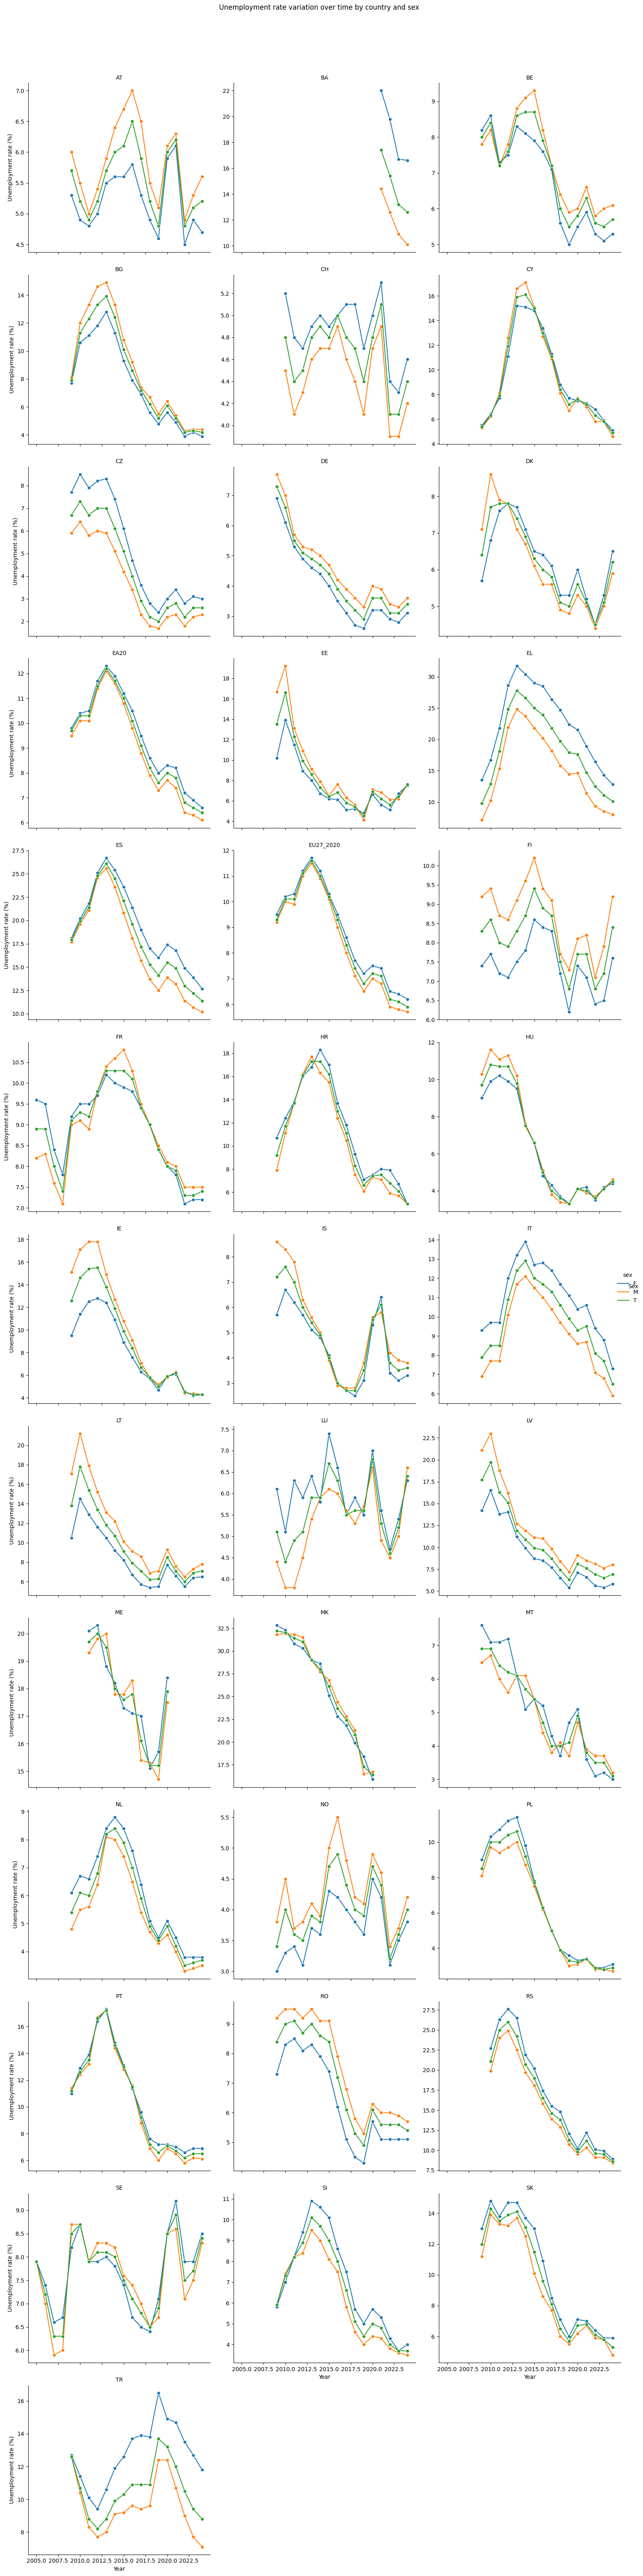

In [9]:
g = sns.relplot(
    data=df,
    x="TIME_PERIOD", y="OBS_VALUE",
    hue="sex", kind="line", marker="o",
    col="geo", col_wrap=3,  # 3 plots per row
    facet_kws={"sharey": False}
)
g.set_axis_labels("Year", "Unemployment rate (%)")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.95)
g.fig.suptitle("Unemployment rate variation over time by country and sex")
g.add_legend(title="Sex")
plt.show()